In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, window_table
from src.strategy import momentum_trend_strategy, momentum_volatility_strategy, momentum_voluratio_strategy
from src.visualization import plot_performance, plot_features

In [2]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = generate_features(base_df)

[*********************100%***********************]  1 of 1 completed


# Features 

/Users/noel/Desktop/quant-research-system/src/visualization.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


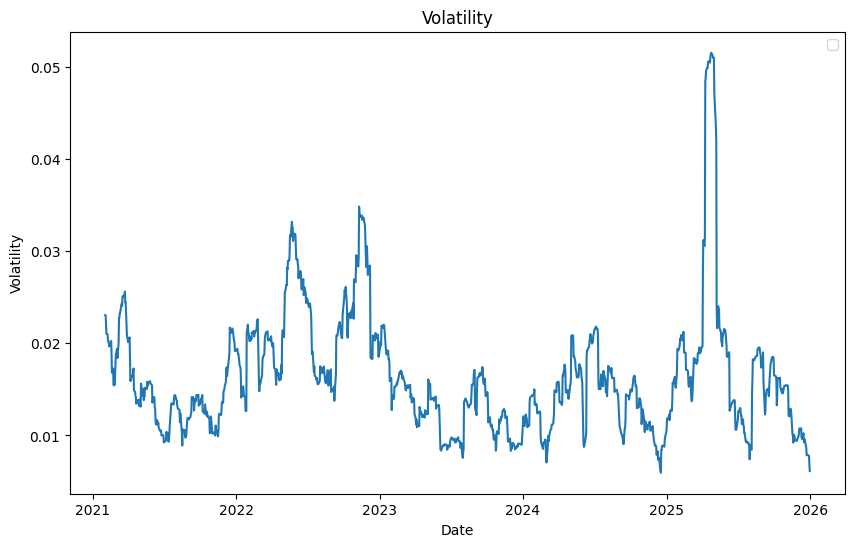

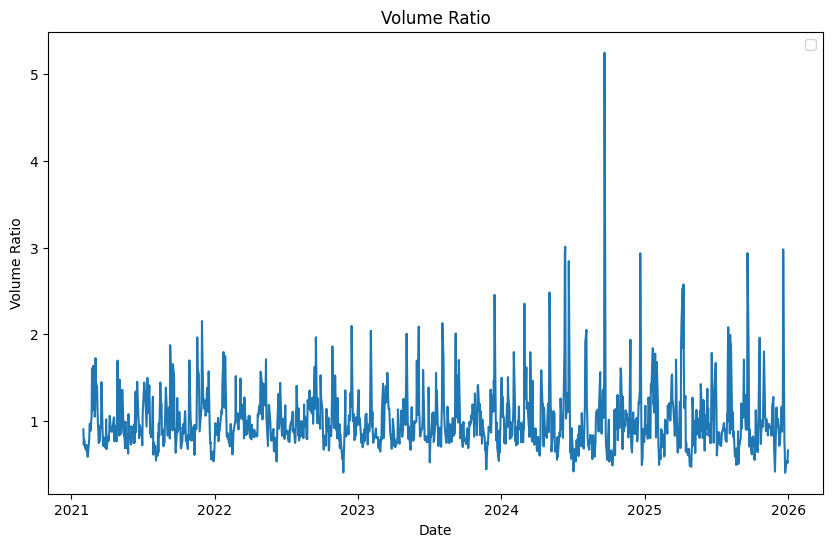

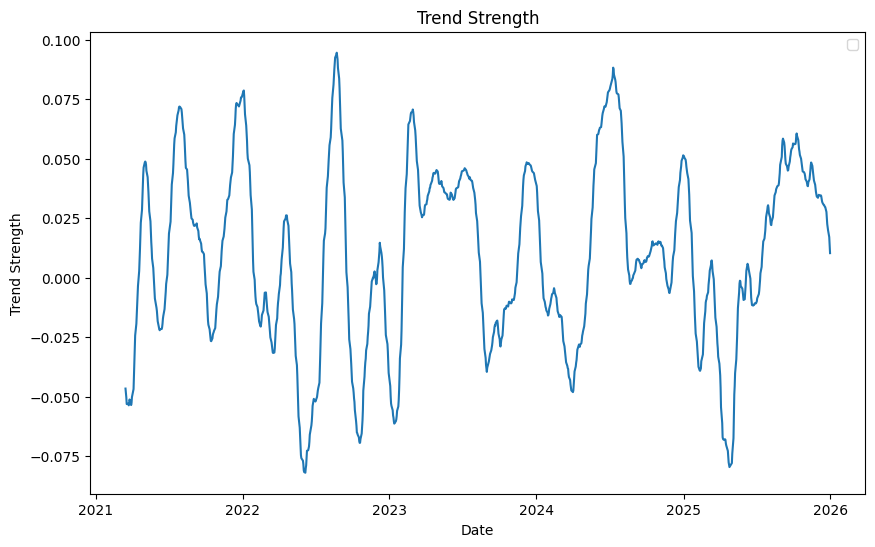

In [3]:
plot_features(base_df)

# Filtered Strategies

## Momentum + Trend Strategy

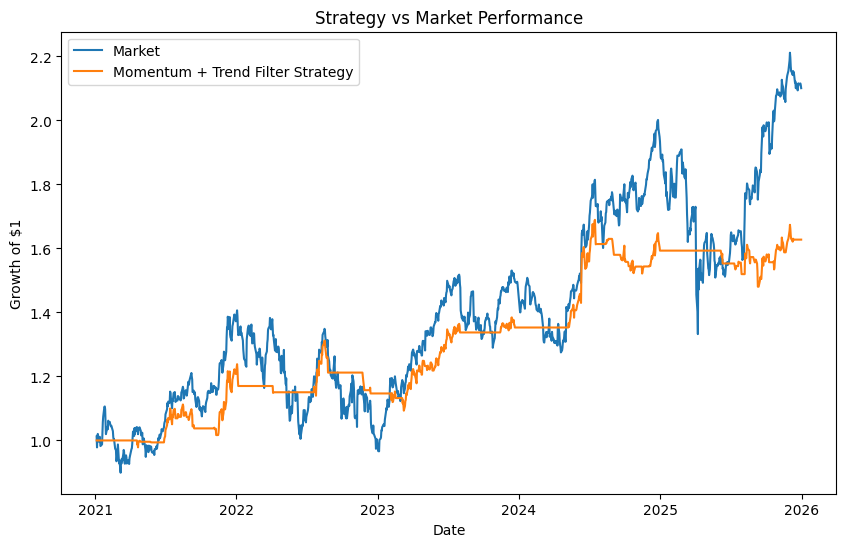

In [4]:
df = base_df.copy()
df = momentum_trend_strategy(df)
df = backtest(df)

plot_performance(df)

In [5]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Momentum + Trend Strength,0.857756,0.122828,-0.167018,0.494821,0.534091,0.353916


## Momentum + Low Volatility Strategy

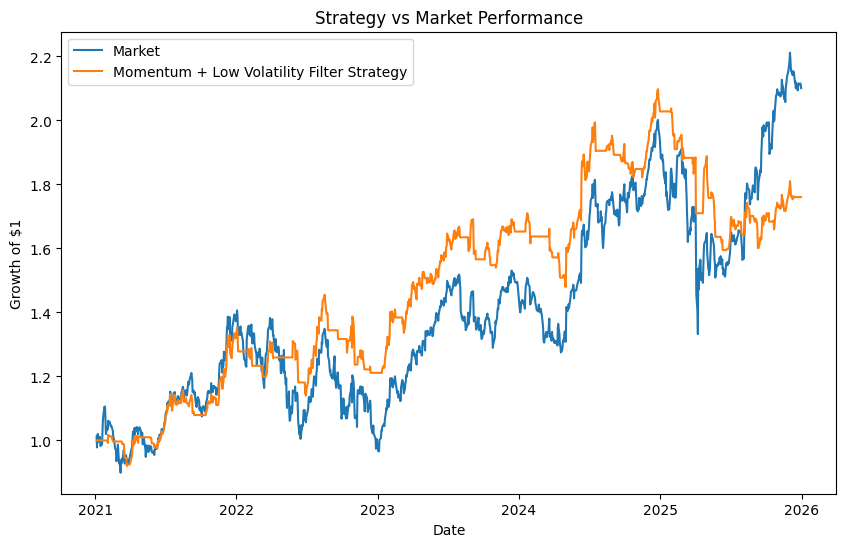

In [6]:
df = base_df.copy()
df = momentum_volatility_strategy(df)
df = backtest(df)

plot_performance(df)

In [7]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Momentum + Rolling Volatility,0.727679,0.177900,-0.239679,0.512351,0.537037,0.567771


## Momentum + Volume Ratio Strategy

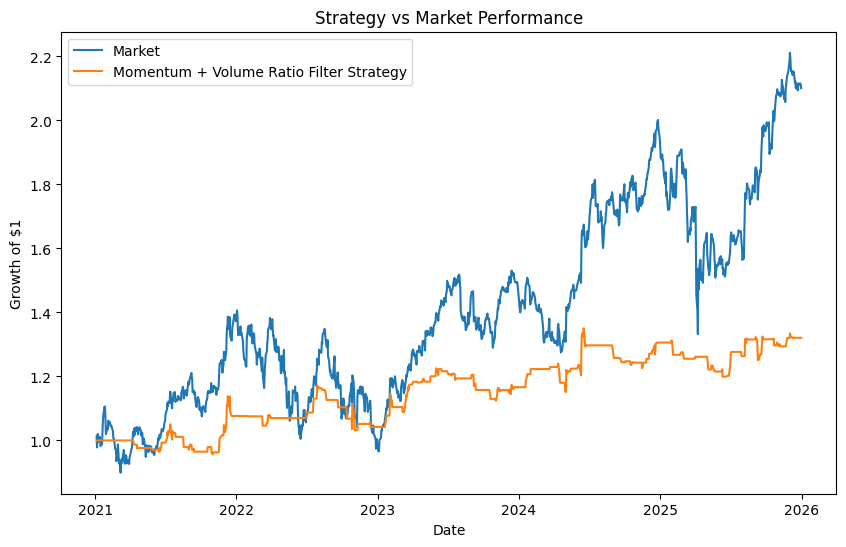

In [8]:
df = base_df.copy()
df = momentum_voluratio_strategy(df)
df = backtest(df)

plot_performance(df)

In [9]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Momentum + Volume Ratio,0.545210,0.114349,-0.120214,0.479681,0.523013,0.188253


# Parameter Testing

In [10]:
windows = range(1, 51)
strategies = [
    ("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", None, None),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", None, None),
    ("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", None, None)
]

In [11]:
df = base_df.copy()
window_table(df, strategies, [5, 10, 20, 50])

,Strategy,Window,Sharpe,Volatility,Max DD


Momentum + Trend Strength
Market Sharpe Ratio: 0.6742
Best Momentum + Trend Strength Strategy window: 14
Best Sharpe ratio: 1.0179



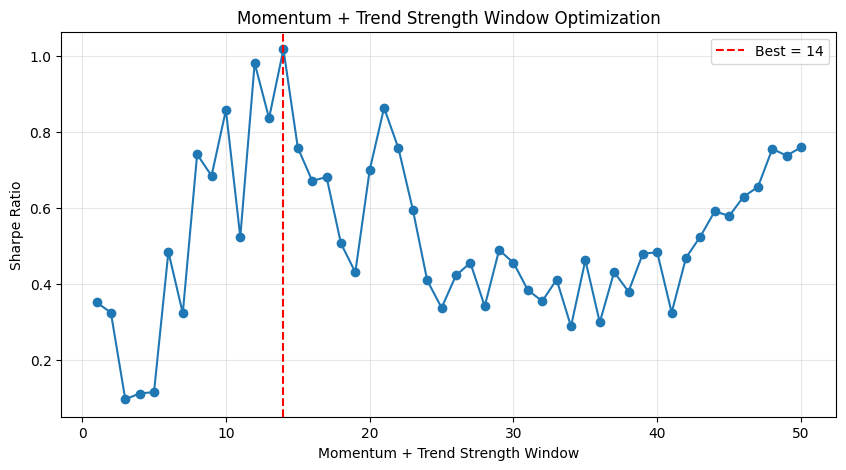

Momentum + Rolling Volatility
Market Sharpe Ratio: 0.6742
Best Momentum + Rolling Volatility Strategy window: 14
Best Sharpe ratio: 1.0332



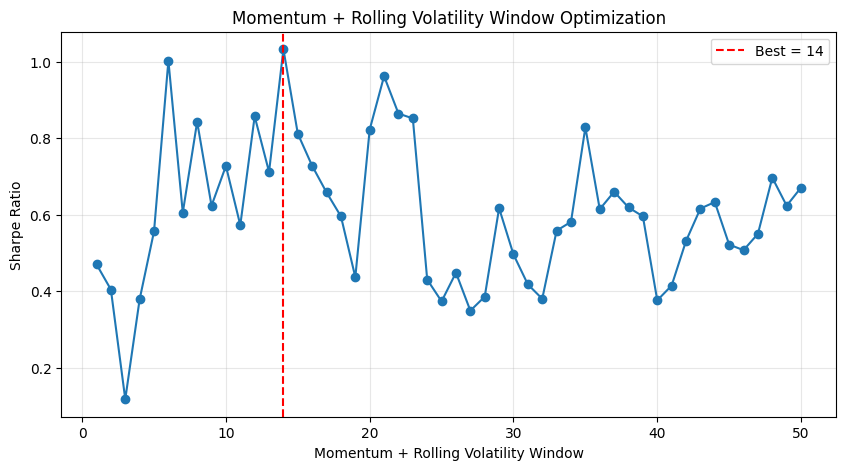

Momentum + Volume Ratio
Market Sharpe Ratio: 0.6742
Best Momentum + Volume Ratio Strategy window: 21
Best Sharpe ratio: 0.9376



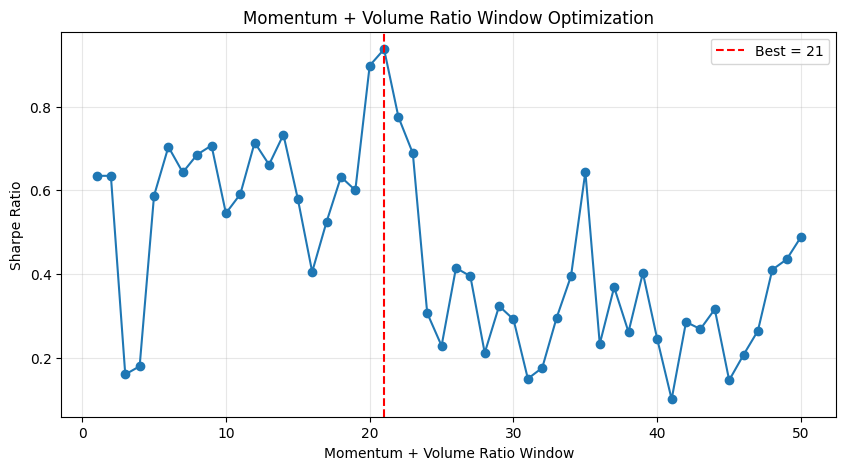

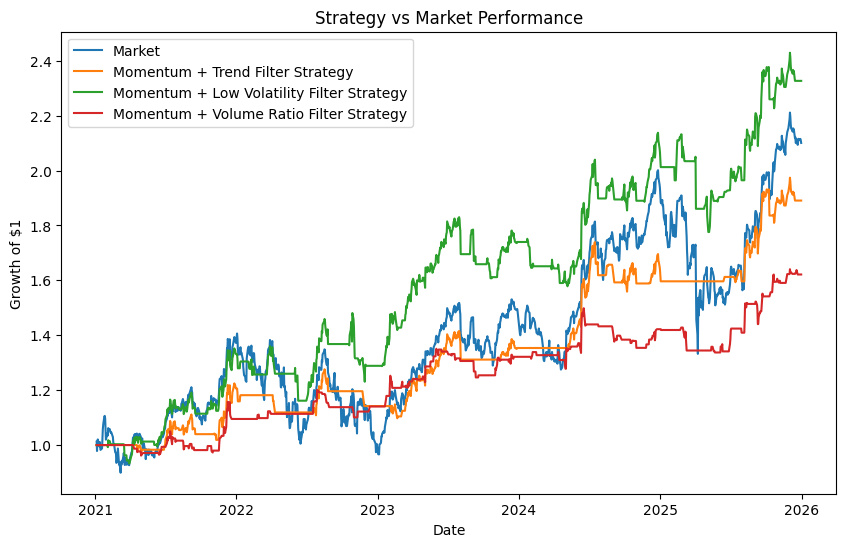

,Strategy,Sharpe,Volatility,Max DD,Signal Accuracy,Signal Precision,Signal Recall
0,Market,0.674159,0.278459,-0.334337,NaN,NaN,NaN
1,Momentum + Trend Strength,1.017947,0.134592,-0.139991,0.509163,0.550420,0.394578
2,Momentum + Rolling Volatility,1.033156,0.179917,-0.169209,0.525896,0.548252,0.590361
3,Momentum + Volume Ratio,0.937567,0.109957,-0.107582,0.483665,0.532520,0.197289


In [12]:
df = base_df.copy()

optimize(df, strategies, windows)